# Coin Flip Simulator

#### Manan Verma
#### 16 May 2026

In [13]:
import math, random
import matplotlib.pyplot as plt

**Below is the distribution of the number of heads vs the number of tails for 10,000 independent coin flips.**

In [14]:
#Count the outcomes of 10,000 coin flips

heads = 0
tails = 0

for i in range (10000):
    if (random.choice(['H', 'T']) == 'H'):
        heads += 1
    else:
        tails += 1

#Print the outcomes
print(f"Heads: {heads} \nTails: {tails}")

Heads: 4995 
Tails: 5005


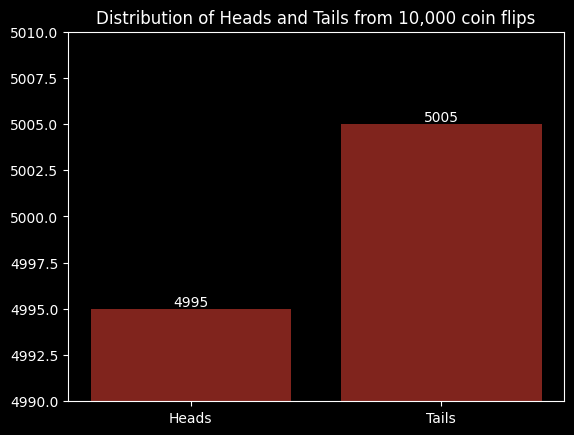

In [15]:
#Plot the distribution of the flips

categories = ['Heads', 'Tails']
distribution = [heads, tails]

plt.bar(categories, distribution)
plt.style.use('dark_background')
plt.title("Distribution of Heads and Tails from 10,000 coin flips")
plt.bar_label(plt.bar(categories, distribution, color = '#80241d'))
#Set the scaling of the vertical axis:
plt.ylim(min(heads, tails) - int(.5 * abs(heads - tails)), max(heads, tails) + int(.5 * abs(heads - tails)))

plt.show()

Clearly, the expected ratio of heads to tail for these 10,000 coin flips would be 5000:5000 (ratio of 1.0). However, every time the simulation is run the observed ratio is likely not exactly that, but rather something close to 1.0. Of course, there is a non-zero probability that the ratio could be as far as 10000:0, though achieving a ratio close to 1.0 has a much higher probability, as the distribution below demonstrates.

***

**Below is the distribution of the number of heads for 10,000 experiments, where one experiment is 10,000 independent coin flips.**

In [16]:
#Simulate 10,000 experiments

def flip_coin():
    """Flip the coin 10,000 times.
       Takes in no input, outputs the number of heads"""
    
    num_heads = 0

    for i in range (10000):
        num_heads += random.getrandbits(1)
    
    return (num_heads)

#Create a list of 10,000 results
heads = []

for i in range (10000):
    heads.append(flip_coin())

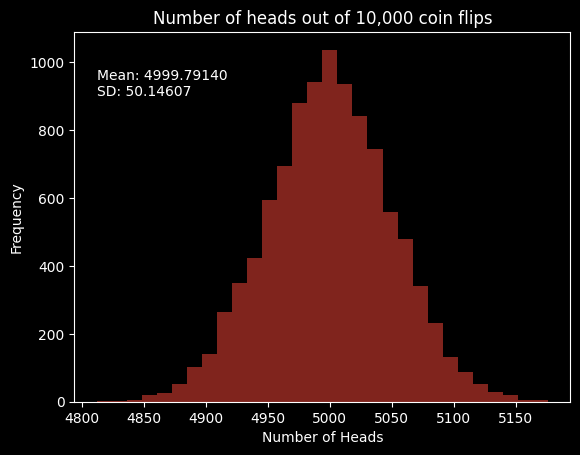

In [17]:
#Plot the distribution of the experiments

plt.hist(heads, bins = 30, color = '#80241d')
plt.style.use('dark_background')
plt.xlabel('Number of Heads')
plt.ylabel('Frequency')
plt.title('Number of heads out of 10,000 coin flips')

#Calculate the mean and standard deviation of the sample flips
mean = sum(heads) / len(heads)
stdev = math.sqrt(sum((x - mean) ** 2 for x in heads) / len(heads))

plt.text(min(heads), 900, f"Mean: {mean:.5f}\nSD: {stdev:.5f}")
plt.show()

This graph is a direct result of the *Central Limit Theorem.* The Central Limit Theorem states that, as the sample size increase and becomes sufficiently large, the sampling distribution of the means will converge to a *Normal Distribution*, regardless of the underlying distribution of the population.  
Mathematically, this is represented as:  

$\bar{X} \sim N(\mu, \frac{\sigma}{n})$  

Where $\bar{X}$ is the sample mean's sampling distribution  
$\mu$ is the underlying population's mean   
$\sigma$ is the underlying population's standard deviation  
and $n$ is the size of the sample.

In this example, the population mean, $\mu$, is 5,000 (since the expected number of heads from 10,000 coin flips is 5,000), and the size of the sample, $n$ is 10,000 (since 10,000 sets of 10,000 coin flips were sampled from). Thus, according to the Central Limit Theorem, the mean number of heads seen from this set of samples will be approximately 5,000, and will be normally distributed as seen in the graph above. 

*Two important ideas should be noted:*  
1. As the size of the sample increases, the standard deviation of the sample mean's distribution ($\frac{\sigma}{n}$) will decrease.  
2. A single coin flip is Bernoulli Distributed since it can be only heads or tails, and a single sample of 10,000 coin flips is Binoimally Distributed. So, every time an experiment is done (flipping the coin 10,000 times), that Binomial Distribution is sampled from. Nonetheless, the distribution of sample means will still follow a Normal Distribution, as described by the Central Limit Theorem.

***

**Below is a visualization of the cumulative average of the number of heads for increasing numbers of coin flips.**

In [18]:
#Calculate the cumulative average from increasing number of coin flips

num_flips = 25000
flips = []

for i in range (num_flips):
    flips.append(random.getrandbits(1))

cum_averages = []
running_sum = 0

for i in range (num_flips):
    running_sum += flips[i]
    cum_averages.append(running_sum / (i+1))

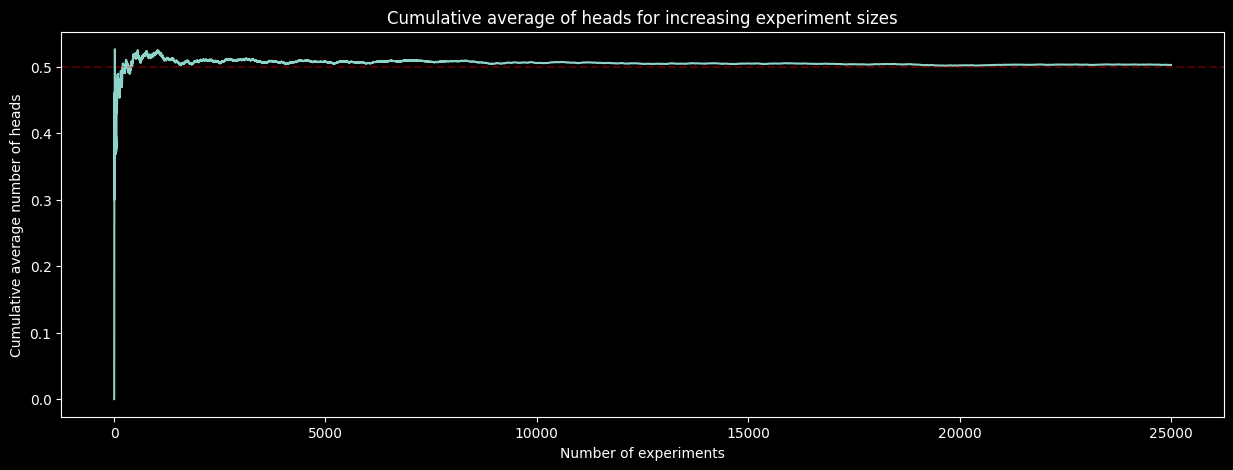

In [19]:
#Plot the cumulative averages

x = range(25000)
plt.style.use('dark_background')
plt.figure(figsize = (15, 5))
plt.plot(x, cum_averages)
plt.axhline(y = 0.5, color = 'r', linestyle = '--', alpha = 0.3)
plt.title("Cumulative average of heads for increasing experiment sizes")
plt.xlabel("Number of experiments")
plt.ylabel("Cumulative average number of heads")

plt.show()

This graph demonstrates the *Law of Large Numbers*, which states that as a sample size grows, its emperical mean will approach the mean of the whole population. Mathematically, this is shown as  
$P(\lim_{n \to \infty} \bar{X}_n = \mu) = 1$  
where $\mu$ is the true mean of the population.  

This equation shows that as we continue to increase the size of the sample (as $n$ approaches $\infty$), the sample's mean will, with a probability of 1.0, approach the population's mean, $\mu$.  
In this scenario, the population has a mean of 0.5, since exactly half of all coin flips are expected to be heads. So, as the number of experiments increases, and the number of samples being used to calculate the mean increases, the observed mean will approach 0.5.

***

**Below is a visualization of the number of heads for an experiment of 1,000 coin flips for increasing numbers of experiments.**

In [20]:
#Simulate different numbers of coin flips, and record the ratio of heads

def flip_coin(num):
    """Flip the coin num times.
       Takes in as input the number of desired coin flips, output the ratio of heads"""
    
    num_heads = 0

    for i in range (num):
        num_heads += random.getrandbits(1)
    
    return float(num_heads / num)

#Create the list of ratios for the differring numbers of coin flips
ratios = []

for i in range (10, 50000, 50):
    ratios.append(flip_coin(i))

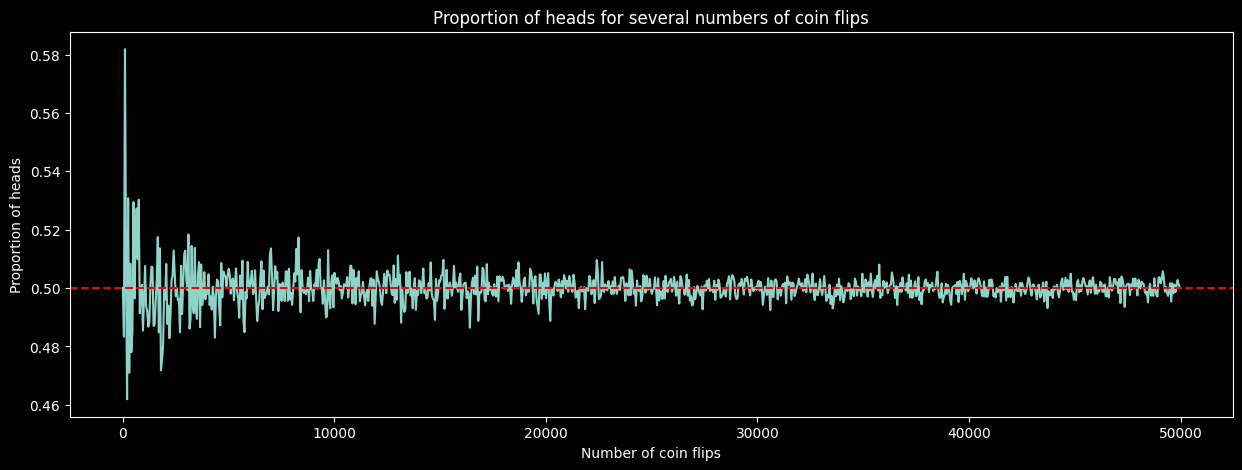

In [21]:
#Plot the ratios

x = range(10, 50000, 50)
plt.style.use('dark_background')
plt.figure(figsize = (15, 5))
plt.plot(x, ratios)
plt.axhline(y = 0.5, color = 'r', linestyle = '--')
plt.title("Proportion of heads for several numbers of coin flips")
plt.xlabel("Number of coin flips")
plt.ylabel("Proportion of heads")

plt.show()

This graph is a direct result of *The Law of Large Numbers*. There are several variations of the Law of Large Numbers (LLN) for differring scenarios including weak LLNs and strong LLNs. In this situation, a strong LLN is the best descriptor since the true true proportion of heads (0.5) is reached almost surely. This graph also shows another important notion within the LLN: that the variation in the observed average decreases as the number of observations increases since $Std(\hat{p}_n) \propto \frac{1}{\sqrt{n}}$, where $n$ is the number of observations. 

***

**Below is a comparision of several different distributions of the number of heads of differring sizes of experiments, where one experiment is 1,000 coin flips.**

In [22]:
#Simulate several different sizes of experiments

def flip_coin():
    """Flip the coin 1,000 times.
       Takes in no input, output the ratio of HEADS to TAILS"""
    
    num_heads = 0
    for i in range (1000):
        num_heads += random.getrandbits(1)    
    return float(num_heads)

#Create 5 lists of different sizes of ratios
ratios_10 = []
ratios_100 = []
ratios_1000 = []
ratios_10000 = []
ratios_100000 = []

for i in range (10):
    ratios_10.append(flip_coin())
for i in range (100):
    ratios_100.append(flip_coin())
for i in range (1000):
    ratios_1000.append(flip_coin())
for i in range (10000):
    ratios_10000.append(flip_coin())
for i in range (100000):
    ratios_100000.append(flip_coin())

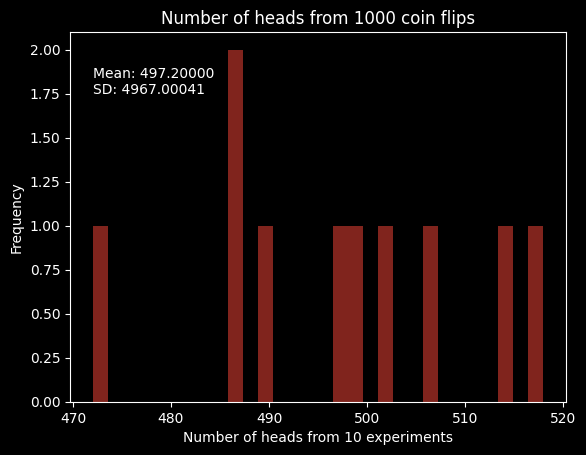

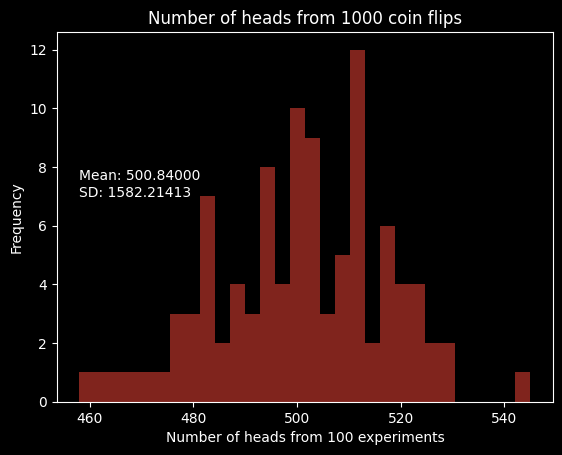

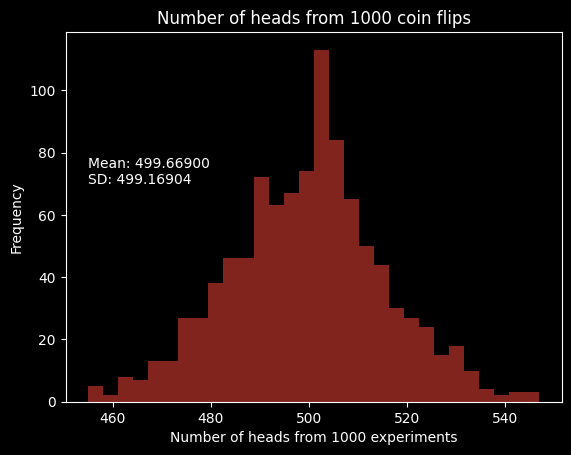

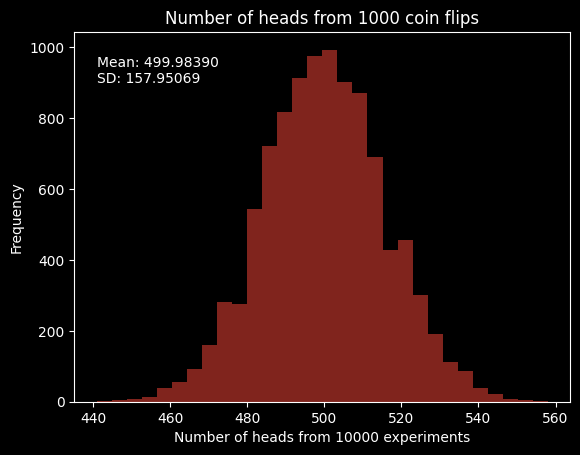

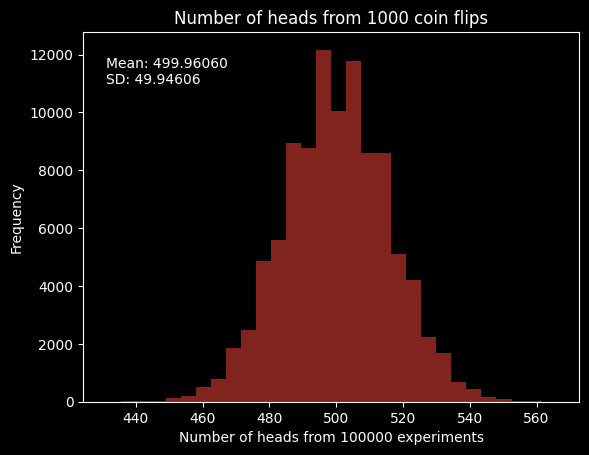

In [23]:
#Plot the distributions of the experiments

plt.hist(ratios_10, bins = 30, color = '#80241d')
plt.style.use('dark_background')
plt.xlabel('Number of heads from 10 experiments')
plt.ylabel('Frequency')
plt.title('Number of heads from 1000 coin flips')

#Calculate the mean and standard deviation of the sample flips
mean = sum(ratios_10) / len(ratios_10)
stdev = math.sqrt(sum((x - mean) ** 2 for x in ratios) / len(ratios_10))
plt.text(min(ratios_10), 1.75, f"Mean: {mean:.5f}\nSD: {stdev:.5f}")

plt.show()

plt.hist(ratios_100, bins = 30, color = '#80241d')
plt.style.use('dark_background')
plt.xlabel('Number of heads from 100 experiments')
plt.ylabel('Frequency')
plt.title('Number of heads from 1000 coin flips')

#Calculate the mean and standard deviation of the sample flips
mean = sum(ratios_100) / len(ratios_100)
stdev = math.sqrt(sum((x - mean) ** 2 for x in ratios) / len(ratios_100))
plt.text(min(ratios_100), 7, f"Mean: {mean:.5f}\nSD: {stdev:.5f}")

plt.show()

plt.hist(ratios_1000, bins = 30, color = '#80241d')
plt.style.use('dark_background')
plt.xlabel('Number of heads from 1000 experiments')
plt.ylabel('Frequency')
plt.title('Number of heads from 1000 coin flips')

#Calculate the mean and standard deviation of the sample flips
mean = sum(ratios_1000) / len(ratios_1000)
stdev = math.sqrt(sum((x - mean) ** 2 for x in ratios) / len(ratios_1000))
plt.text(min(ratios_1000), 70, f"Mean: {mean:.5f}\nSD: {stdev:.5f}")

plt.show()

plt.hist(ratios_10000, bins = 30, color = '#80241d')
plt.style.use('dark_background')
plt.xlabel('Number of heads from 10000 experiments')
plt.ylabel('Frequency')
plt.title('Number of heads from 1000 coin flips')

#Calculate the mean and standard deviation of the sample flips
mean = sum(ratios_10000) / len(ratios_10000)
stdev = math.sqrt(sum((x - mean) ** 2 for x in ratios) / len(ratios_10000))
plt.text(min(ratios_10000), 900, f"Mean: {mean:.5f}\nSD: {stdev:.5f}")

plt.show()

plt.hist(ratios_100000, bins = 30, color = '#80241d')
plt.style.use('dark_background')
plt.xlabel('Number of heads from 100000 experiments')
plt.ylabel('Frequency')
plt.title('Number of heads from 1000 coin flips')

#Calculate the mean and standard deviation of the sample flips
mean = sum(ratios_100000) / len(ratios_100000)
stdev = math.sqrt(sum((x - mean) ** 2 for x in ratios) / len(ratios_100000))
plt.text(min(ratios_100000), 11000, f"Mean: {mean:.5f}\nSD: {stdev:.5f}")

plt.show()